In [1]:
#Import packages
import numpy as np
import json, copy
import hasasia.sensitivity as hsen
import hasasia.skymap as hsky
import hasasia.utils as hutils
import hasasia.sim as hsim
import holodeck as holo
import matplotlib.pyplot as plt
from astropy import units as utils
from astropy import constants as c
from astropy.coordinates import SkyCoord
import healpy as hp
import matplotlib.cm as cm
#from la_forge.utils import set_publication_params
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import holodeck as holo
from holodeck.constants import GYR, MSOL, PC, YR

import scipy.linalg as sl
import discovery as ds


# Setting various healpy quantities and GW source sky positions.
NSIDE = 8
NPIX = hp.nside2npix(NSIDE)
IPIX = np.arange(NPIX)
theta_gw, phi_gw = hp.pix2ang(nside=NSIDE,ipix=IPIX)

# Get data
# Faithful NG20 + a few more years of NG20-like + DSA

Faithful NG20:
i) Starting from NG20 par and tim files
ii) Tuned with WN such that its 15year slice has a GWB SNR~5

A few more years of NG20-like: 
Continue our NG20 observing strategy (telescopes and cadence) until December 31, 2027

DSA:
Switch to observing pulsars with DSA and CHIME starting January 1, 2028
The TOA errors for DSA/CHIME are from @Tyler Cohen. The observations go up until January 1, 2030."

In [2]:
import glob
ng20_gwb = '/Users/ashokan/osu/sarahspta/data/NG_DSA_irn/'
pardir = ng20_gwb
timdir = ng20_gwb
pars = sorted(glob.glob(pardir+'*.par'))
tims = sorted(glob.glob(timdir+'*.tim'))
#check number of pulsars
print(len(pars))
print(len(tims))

#check first par and tim files
print(pars[0])
print(tims[0])


80
80
/Users/ashokan/osu/sarahspta/data/NG_DSA_irn/B1855+09.par
/Users/ashokan/osu/sarahspta/data/NG_DSA_irn/B1855+09.tim


In [3]:
#make enterprise pulsars
from enterprise.pulsar import Pulsar as ePulsar
ePsrs = []
for par,tim in zip(pars,tims):
    ePsr = ePulsar(par, tim,  ephem='DE440')
    ePsrs.append(ePsr)
    print('\rPSR {0} complete'.format(ePsr.name),end='',flush=True)

/opt/homebrew/Caskroom/mambaforge/base/envs/sarahspta/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
libstempo not installed. PINT or libstempo are required to use par and tim files.
2026-07-08 19:04:38.797 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2026-07-08 19:04:38.977 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2026-07-08 19:04:38.980 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-07-08 19:04:38.986 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-07-08 19:04:38.986 | DEBUG    | p

PSR B1855+09 complete

2026-07-08 19:04:54.216 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2026-07-08 19:04:54.458 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2026-07-08 19:04:54.461 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-07-08 19:04:54.467 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-07-08 19:04:54.467 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2026-07-08 19:04:54.468 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2026-07-08 19:04:54.535 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-07-08 19:04:54.536 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

PSR B1937+21 complete

2026-07-08 19:04:55.816 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2026-07-08 19:04:55.950 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2026-07-08 19:04:55.952 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-07-08 19:04:55.957 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-07-08 19:04:55.957 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2026-07-08 19:04:55.958 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2026-07-08 19:04:56.006 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-07-08 19:04:56.008 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

...

PSR J2302+4442 complete

2026-07-08 19:06:31.517 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2026-07-08 19:06:31.737 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2026-07-08 19:06:31.741 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-07-08 19:06:31.753 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-07-08 19:06:31.753 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2026-07-08 19:06:31.754 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2026-07-08 19:06:31.864 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-07-08 19:06:31.866 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

PSR J2317+1439 complete

2026-07-08 19:06:33.302 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2021 from the given model
2026-07-08 19:06:33.437 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2026-07-08 19:06:33.440 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2026-07-08 19:06:33.443 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-07-08 19:06:33.443 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock correction (~27 us)
2026-07-08 19:06:33.444 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2026-07-08 19:06:33.485 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2026-07-08 19:06:33.486 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2021) clock co

PSR J2322+2057 complete

In [ ]:
# #save these as a pickle file
# import pickle
# with open('ePsrs_ng20_few_more_years_ng20_DSA.pkl', 'wb') as f:
#     pickle.dump(ePsrs, f)   

Timespan of the dataset: 25.681867062125047 years
Telescopes in the dataset: ['arecibo' 'arecibo' 'arecibo' ... 'chime' 'chime' 'chime']
Pulsars with DSA in the dataset: []


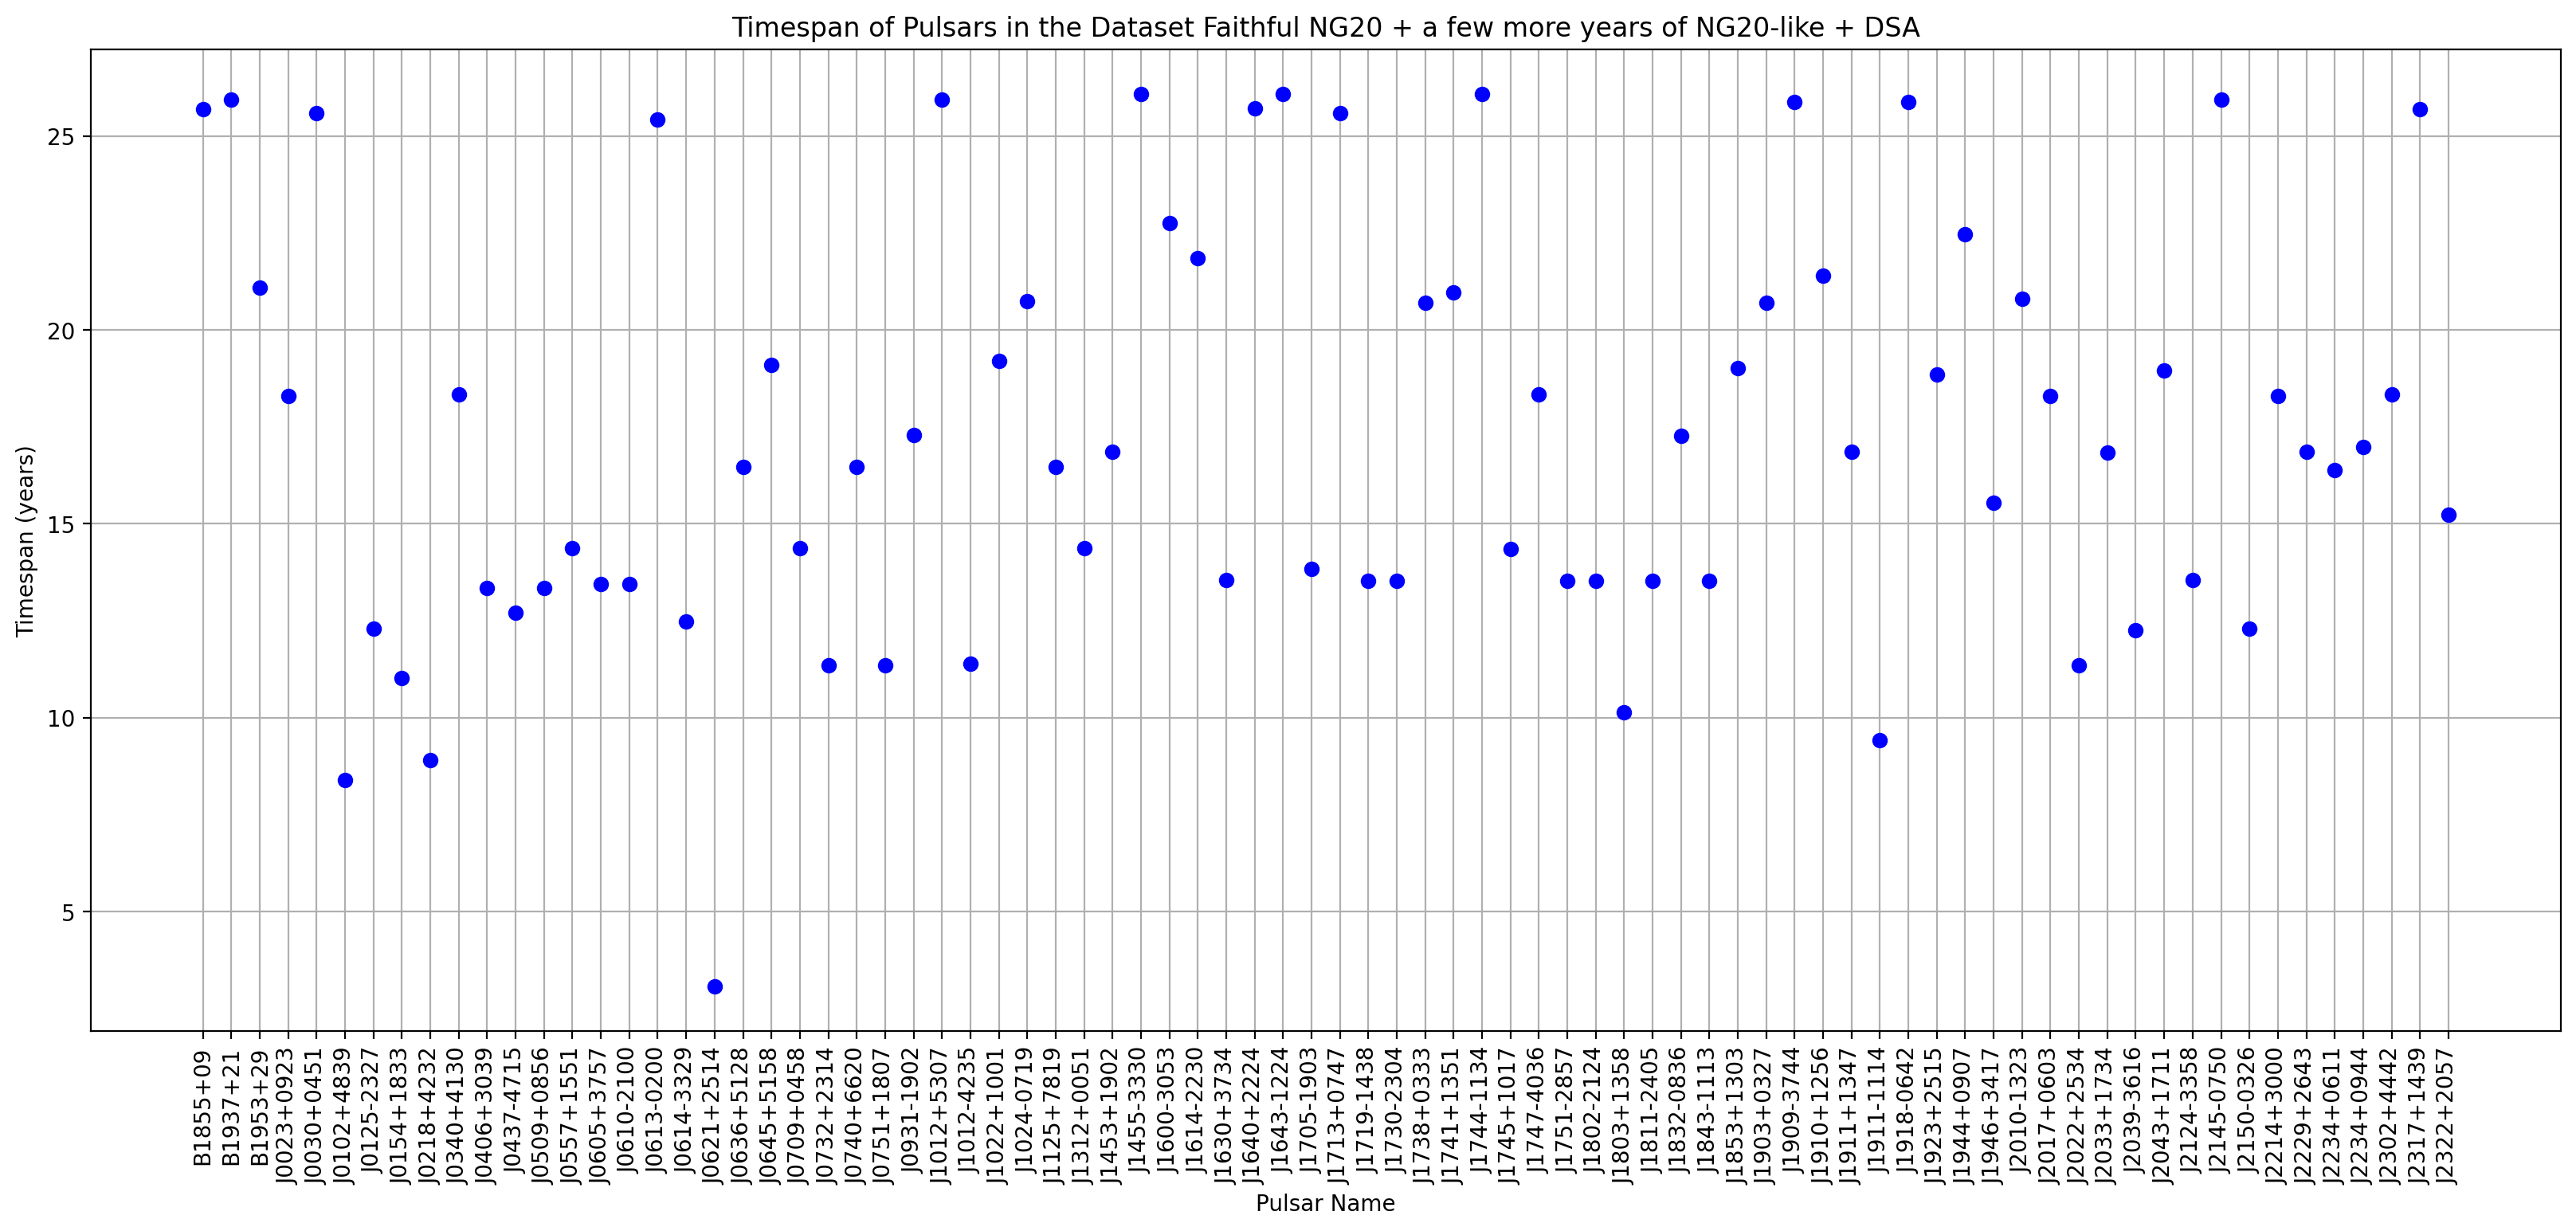

In [36]:
#what is the timespan of the dataset
t_span = ePsrs[0].toas.max() - ePsrs[0].toas.min()
print('Timespan of the dataset: {0} years'.format(t_span/(356*86400)))

#make a plot of pulsar name vs timespan
plt.figure(figsize=(20,8))
for ePsr in ePsrs:
    t_span = ePsr.toas.max() - ePsr.toas.min()
    plt.plot(ePsr.name, t_span/(356*86400), 'o', color='blue')
plt.xlabel('Pulsar Name')
plt.ylabel('Timespan (years)')  
plt.title('Timespan of Pulsars in the Dataset Faithful NG20 + a few more years of NG20-like + DSA')
plt.xticks(rotation=90)
plt.savefig('timespan_of_pulsars.png', bbox_inches='tight')
plt.grid()

#what telescopes are in the dataset
print('Telescopes in the dataset:', ePsr._telescope)

#which pulsars have DSA in the dataset
dsa_pulsars = []
for ePsr in ePsrs:
    if 'CHIME-DSA1650' in ePsr._telescope:
        dsa_pulsars.append(ePsr.name)
print('Pulsars with DSA in the dataset:', dsa_pulsars)

# #visualize the telescope vs pulsars observed information in a way that shows which pulsars are observed by which telescopes
# plt.figure(figsize=(20,8))
# for ePsr in ePsrs:
#     for tel in ePsr._telescope:
#         plt.plot(ePsr.name, tel, 'o', color='blue')
# plt.xlabel('Pulsar Name')
# plt.ylabel('Telescope')
# plt.title('Telescopes Observing Pulsars in the Dataset Faithful NG20 + a few more years of NG20-like + DSA')
# plt.xticks(rotation=90)
# plt.grid()  

In [56]:
# #find unique telescopes in the dataset
# for ePsr in ePsrs:
#     print(ePsr.name, np.unique(ePsr.backend_flags))

#which pulsars have DSA in the dataset, look for backend flag CHIME-DSA1650
dsa_pulsars = []
for ePsr in ePsrs:
    if 'CHIME-DSA1650' in ePsr.backend_flags:
        dsa_pulsars.append(ePsr.name)
    if 'DSA1650' in ePsr.backend_flags:
        dsa_pulsars.append(ePsr.name)
print('Pulsars with DSA in the dataset:', dsa_pulsars)
print('Number of pulsars with DSA in the dataset:', len(dsa_pulsars))


Pulsars with DSA in the dataset: ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451', 'J0125-2327', 'J0154+1833', 'J0340+4130', 'J0406+3039', 'J0509+0856', 'J0557+1551', 'J0605+3757', 'J0610-2100', 'J0613-0200', 'J0614-3329', 'J0636+5128', 'J0645+5158', 'J0709+0458', 'J0732+2314', 'J0740+6620', 'J0751+1807', 'J0931-1902', 'J1012+5307', 'J1022+1001', 'J1024-0719', 'J1125+7819', 'J1312+0051', 'J1453+1902', 'J1455-3330', 'J1600-3053', 'J1614-2230', 'J1630+3734', 'J1640+2224', 'J1643-1224', 'J1705-1903', 'J1713+0747', 'J1719-1438', 'J1730-2304', 'J1738+0333', 'J1741+1351', 'J1744-1134', 'J1745+1017', 'J1747-4036', 'J1751-2857', 'J1802-2124', 'J1803+1358', 'J1811-2405', 'J1832-0836', 'J1843-1113', 'J1853+1303', 'J1903+0327', 'J1909-3744', 'J1910+1256', 'J1911+1347', 'J1911-1114', 'J1918-0642', 'J1923+2515', 'J1944+0907', 'J1946+3417', 'J2010-1323', 'J2017+0603', 'J2022+2534', 'J2033+1734', 'J2039-3616', 'J2043+1711', 'J2124-3358', 'J2145-0750', 'J2150-0326', 'J2214+3000', 'J2229

In [57]:
#find all uniqe backend flags in the dataset
unique_backend_flags = set()
for ePsr in ePsrs:
    unique_backend_flags.update(ePsr.backend_flags)
print('Unique backend flags in the dataset:', unique_backend_flags)

Unique backend flags in the dataset: {np.str_('S-wide_ASP'), np.str_('S-wide_PUPPI'), np.str_('327_ASP'), np.str_('DSA1650'), np.str_('Rcvr_800_GUPPI'), np.str_('L-wide_ASP'), np.str_('Rcvr_800_VEGAS'), np.str_('430_ASP'), np.str_('327_PUPPI'), np.str_('CHIME'), np.str_('Rcvr1_2_VEGAS'), np.str_('Rcvr1_2_GUPPI'), np.str_('3GHz_YUPPI'), np.str_('Rcvr1_2_GASP'), np.str_('L-wide_PUPPI'), np.str_('1.5GHz_YUPPI'), np.str_('430_PUPPI'), np.str_('CHIME-DSA1650'), np.str_('CHIME_daily'), np.str_('Rcvr_800_GASP')}


In [ ]:
#Make GBT only and start at a point where DSA switches on for a year with 600h